In [16]:
from logicqubit.logic import *
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from openfermion.chem import MolecularData
from openfermion.transforms import get_fermion_operator, jordan_wigner, bravyi_kitaev, parity_code
from openfermion.linalg import get_ground_state, get_sparse_operator
from openfermionpyscf import run_pyscf
from cmath import *
import numpy as np
import scipy
from scipy.optimize import *
import matplotlib.pyplot as plt

## Fundamentação teórica do VQE para a molécula de $H_2$

A descrição da molécula de $H_2$ começa pela Hamiltoniana molecular completa:

\begin{eqnarray*}
    \hat{H}_{mol}
    =
    -\sum_A \frac{1}{2M_A}\nabla_A^2
    -\sum_i \frac{1}{2}\nabla_i^2
    +\sum_{A<B}\frac{Z_AZ_B}{R_{AB}}
    -\sum_{A,i}\frac{Z_A}{r_{iA}}
    +\sum_{i<j}\frac{1}{r_{ij}} .
\end{eqnarray*}

Usando a aproximação de Born-Oppenheimer, despreza-se o movimento dos núcleos e obtém-se a Hamiltoniana eletrônica:

\begin{eqnarray*}
    \hat{H}_{ele}(r)
    =
    -\frac{1}{2}\sum_i \nabla_i^2
    -\sum_{A,i}\frac{Z_A}{r_{iA}}
    +\sum_{i<j}\frac{1}{r_{ij}} .
\end{eqnarray*}

Em segunda quantização, essa Hamiltoniana pode ser escrita como:

\begin{eqnarray*}
    \mathcal{H}(r)
    =
    h_0
    + \sum_{pq} h_{pq}(r)\, a^{\dagger}_p a_q
    + \frac{1}{2} \sum_{pqrs} h_{pqrs}(r)\, a^{\dagger}_p a^{\dagger}_q a_r a_s .
\end{eqnarray*}

Os integrais de um e dois corpos são dados por:

\begin{eqnarray*}
    h_{pq}(r)
    =
    \int d\mathbf{r}\,\phi_p^*(\mathbf{r})
    \left(
    -\frac{1}{2}\nabla^2
    -\sum_a \frac{Z_a}{r_{a,\mathbf{r}}}
    \right)\phi_q(\mathbf{r}),
\end{eqnarray*}

\begin{eqnarray*}
    h_{pqrs}(r)
    =
    \int d\mathbf{r}_1\,d\mathbf{r}_2\,
    \phi_p^*(\mathbf{r}_1)\phi_q^*(\mathbf{r}_2)
    \frac{1}{r_{12}}
    \phi_r(\mathbf{r}_1)\phi_s(\mathbf{r}_2).
\end{eqnarray*}

Em seguida, aplica-se a transformação de Jordan-Wigner para mapear os operadores fermiônicos em operadores de qubit:

\begin{eqnarray*}
    a^{\dagger}_j = I^{\otimes j-1}\otimes \sigma_{-} \otimes \sigma_{z}^{\otimes N-j}\\
    a_j = I^{\otimes j-1}\otimes \sigma_{+} \otimes \sigma_{z}^{\otimes N-j}
\end{eqnarray*}

Assim, a Hamiltoniana eletrônica passa a ser escrita como uma soma de strings de Pauli:

\begin{eqnarray*}
    H_q(r)=\sum_k c_k(r) P_k .
\end{eqnarray*}

Por fim, o método VQE estima a energia do estado fundamental minimizando o valor esperado da Hamiltoniana:

\begin{eqnarray*}
    E(\theta)
    =
    \langle \psi(\theta) | H_q(r) | \psi(\theta) \rangle
    =
    \sum_k c_k(r)\langle \psi(\theta) | P_k | \psi(\theta) \rangle .
\end{eqnarray*}

## Fluxo do código

O código percorre diferentes valores da distância internuclear $r$, constrói a molécula de $H_2$ para cada geometria e calcula sua Hamiltoniana eletrônica com PySCF/OpenFermion. Depois, aplica a transformação de Jordan-Wigner para obter a Hamiltoniana em qubits e executa o VQE com um ansatz variacional de 4 qubits, tanto com LogicQuBit quanto com Qiskit. Em paralelo, também calcula a energia exata por diagonalização direta da Hamiltoniana, armazenando os resultados para comparar os métodos e, ao final, plotar a curva de dissociação da molécula.

In [17]:
gates = Gates(1)

ID = gates.ID()
X = gates.X()
Y = gates.Y()
Z = gates.Z()

Repulsion energy (Eh): 0.7055696793059831
step = 01 | distance = 0.3000 | exact = -0.6018 | logicqubit = -0.6018 | l_error = 1.77e-07 | qiskit = -0.6018 | q_error = 1.77e-07
step = 02 | distance = 0.3564 | exact = -0.8082 | logicqubit = -0.8082 | l_error = 1.75e-07 | qiskit = -0.8082 | q_error = 1.75e-07
step = 03 | distance = 0.4128 | exact = -0.9390 | logicqubit = -0.9390 | l_error = 2.00e-07 | qiskit = -0.9390 | q_error = 2.00e-07
step = 04 | distance = 0.4692 | exact = -1.0230 | logicqubit = -1.0230 | l_error = 2.52e-07 | qiskit = -1.0230 | q_error = 2.52e-07
step = 05 | distance = 0.5256 | exact = -1.0764 | logicqubit = -1.0764 | l_error = 2.57e-07 | qiskit = -1.0764 | q_error = 2.57e-07
step = 06 | distance = 0.5821 | exact = -1.1091 | logicqubit = -1.1091 | l_error = 2.86e-07 | qiskit = -1.1091 | q_error = 2.86e-07
step = 07 | distance = 0.6385 | exact = -1.1275 | logicqubit = -1.1275 | l_error = 3.37e-07 | qiskit = -1.1275 | q_error = 3.37e-07
step = 08 | distance = 0.6949 | ex

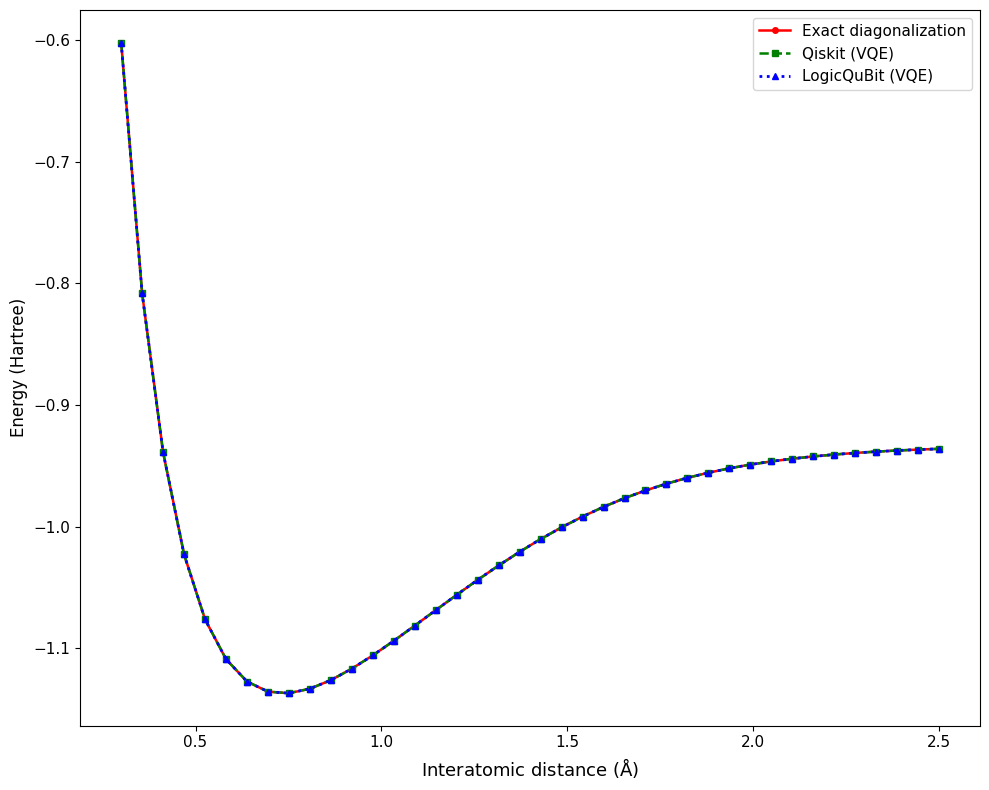

In [18]:
def get_molecule(distance = 0.75):
    # Build the qubit Hamiltonian of H2 for a given bond distance.
    geometry = [('H', (0., 0., 0.)), ('H', (0., 0., distance))]
    basis = "sto-3g"
    multiplicity = 1
    charge = 0
    description = "H2"

    molecule_h2 = MolecularData(geometry, basis, multiplicity, charge, description)  # Build H2 molecule
    molecule_h2 = run_pyscf(molecule_h2, run_scf=1, verbose=0)  # Run electronic structure calculation
    molecule_h2 = jordan_wigner(get_fermion_operator(molecule_h2.get_molecular_hamiltonian()))  # Map fermions to qubits

    mol_gates = list(molecule_h2.terms.keys())
    mol_co = list(molecule_h2.terms.values())
    return mol_gates, mol_co

def get_sigma(gate_name):
    # Return the matrix associated with a Pauli label.
    if gate_name == 'X':
        gate = X  # Pauli X
    elif gate_name == 'Y':
        gate = Y  # Pauli Y
    elif gate_name == 'Z':
        gate = Z  # Pauli Z
    else:
        gate = ID  # Identity
    return gate

def get_H_k(mol_gates):
    # Convert Pauli terms into full 4-qubit tensor-product operators.
    gate_list = []
    name_list = []
    for pauli_gate in mol_gates:
        prod_list = [get_sigma('I') for _ in range(4)]  # Start with identities
        name_gate_list = ['I' for _ in range(4)]
        for term in pauli_gate:
            prod_list[3-term[0]] = get_sigma(term[1])  # Place Pauli on the right qubit
            name_gate_list[3-term[0]] = term[1]
        gate_kron = prod_list[0]
        for item in prod_list[1:]:
            gate_kron = gate_kron.kron(item)  # Build tensor product
        gate_list.append(gate_kron)
        name_list.append(name_gate_list)
    return gate_list, name_list

def get_base(mol_gate):
    # Build the eigenvalue-sign pattern used in expectation values.
    prod_list = [Matrix([1, 1]) for _ in range(4)]  # Default eigenvalue pattern
    if isinstance(mol_gate, tuple):
        for item in mol_gate:
            prod_list[3-item[0]] = Matrix([1, -1])  # Non-identity changes sign pattern
    else:
        gate_list = list(mol_gate)
        for i, item in enumerate(gate_list):
            if item != 'I':
                prod_list[i] = Matrix([1, -1])
    base_kron = prod_list[0]
    for item in prod_list[1:]:
        base_kron = base_kron.kron(item)  # Build tensor product pattern
    return base_kron

def sum(items):
    # Sum matrix-like objects with the same interface.
    value = items[0]
    for item in items[1:]:
        value = value + item  # Custom sum for matrix-like objects
    return value

def repulsion_energy(Z1=1, Z2=1, r=75e-12):
    # Compute the nuclear repulsion energy in Hartree units.
    Eh = 4.3597447222071e-18
    ep0 = 8.854187e-12
    e = -1.602176634e-19
    return (1/(4*pi*ep0)*(Z1*Z2*e**2)/r)/Eh  # Nuclear repulsion in Hartree

rep_energy = repulsion_energy()
print("Repulsion energy (Eh): %s" % rep_energy)

def expectation_value(measurements, base=np.array([ 1, -1, -1,  1, -1,  1,  1, -1,
                                                   -1,  1,  1, -1,  1, -1, -1,  1])):
    # Compute an expectation value from probabilities and eigenvalues.
    probabilities = np.array(measurements)
    expectation = np.sum(base * probabilities)  # Sum eigenvalues weighted by probabilities
    return expectation.real

def pauli_name(pauli_gate):
    # Convert a Pauli term into its string representation.
    name = ['I'] * 4
    for qubit, op in pauli_gate:
        name[3-qubit] = op  # Convert term into string form
    return ''.join(name)

def ansatz_4q4(q1, q2, q3, q4, params):
    # Prepare the variational state in LogicQuBit.
    q1.RY(params[0])  # Variational rotation
    q2.RZ(params[1])
    q3.RY(params[2])
    q4.RZ(params[3])
    q2.CNOT(q1)  # Entangling layer
    q3.CNOT(q2)
    q4.CNOT(q3)

def ansatz_4q4_qiskit(qc, params):
    # Prepare the same variational state in Qiskit.
    qc.ry(params[0], 0)
    qc.rz(params[1], 1)
    qc.ry(params[2], 2)
    qc.rz(params[3], 3)
    qc.cx(0, 1)  # Entangling layer
    qc.cx(1, 2)
    qc.cx(2, 3)

def qiskit_probabilities(qc):
    # Return exact computational-basis probabilities from the statevector.
    sv = Statevector.from_instruction(qc)
    return np.array(sv.probabilities(), dtype=float)

def sigma_zzzz(params, use_logicqubit=True):
    # Measure all commuting Z-string expectation values at once.
    if use_logicqubit:
        logicQuBit = LogicQuBit(4, first_left=False)
        q1 = Qubit()
        q2 = Qubit()
        q3 = Qubit()
        q4 = Qubit()
        ansatz_4q4(q1, q2, q3, q4, params)
        result = logicQuBit.Measure([q1, q2, q3, q4]) # These Z-string operators commute ([A,B]=0)
    else:
        qc = QuantumCircuit(4)
        ansatz_4q4_qiskit(qc, params)
        result = qiskit_probabilities(qc)

    iiiz = expectation_value(result, get_base('IIIZ').get())
    iizi = expectation_value(result, get_base('IIZI').get())
    izii = expectation_value(result, get_base('IZII').get())
    ziii = expectation_value(result, get_base('ZIII').get())
    iizz = expectation_value(result, get_base('IIZZ').get())
    iziz = expectation_value(result, get_base('IZIZ').get())
    ziiz = expectation_value(result, get_base('ZIIZ').get())
    izzi = expectation_value(result, get_base('IZZI').get())
    zizi = expectation_value(result, get_base('ZIZI').get())
    zzii = expectation_value(result, get_base('ZZII').get())

    return iiiz, iizi, izii, ziii, iizz, iziz, ziiz, izzi, zizi, zzii

def sigma_yxxy(params, use_logicqubit=True):
    # Measure the expectation value of the YXXY Pauli string.
    if use_logicqubit:
        logicQuBit = LogicQuBit(4, first_left=False)
        q1 = Qubit()
        q2 = Qubit()
        q3 = Qubit()
        q4 = Qubit()
        ansatz_4q4(q1, q2, q3, q4, params)
        q2.RY(-pi/2)  # Basis rotation
        q3.RY(-pi/2)
        q1.RX(pi/2)
        q4.RX(pi/2)
        result = logicQuBit.Measure([q1, q2, q3, q4]) # Measure in rotated basis
    else:
        qc = QuantumCircuit(4)
        ansatz_4q4_qiskit(qc, params)
        qc.ry(-pi/2, 1)  # Basis rotation
        qc.ry(-pi/2, 2)
        qc.rx(pi/2, 0)
        qc.rx(pi/2, 3)
        result = qiskit_probabilities(qc) # Measure in rotated basis

    result = expectation_value(result)
    return result

def sigma_xyyx(params, use_logicqubit=True):
    # Measure the expectation value of the XYYX Pauli string.
    if use_logicqubit:
        logicQuBit = LogicQuBit(4, first_left=False)
        q1 = Qubit()
        q2 = Qubit()
        q3 = Qubit()
        q4 = Qubit()
        ansatz_4q4(q1, q2, q3, q4, params)
        q1.RY(-pi/2)  # Basis rotation
        q4.RY(-pi/2)
        q2.RX(pi/2)
        q3.RX(pi/2)
        result = logicQuBit.Measure([q1, q2, q3, q4])  # Measure in rotated basis
    else:
        qc = QuantumCircuit(4)
        ansatz_4q4_qiskit(qc, params)
        qc.ry(-pi/2, 0)
        qc.ry(-pi/2, 3)
        qc.rx(pi/2, 1)
        qc.rx(pi/2, 2)
        result = qiskit_probabilities(qc) # Measure in rotated basis

    result = expectation_value(result)
    return result

def sigma_xxyy(params, use_logicqubit=True):
    # Measure the expectation value of the XXYY Pauli string.
    if use_logicqubit:
        logicQuBit = LogicQuBit(4, first_left=False)
        q1 = Qubit()
        q2 = Qubit()
        q3 = Qubit()
        q4 = Qubit()
        ansatz_4q4(q1, q2, q3, q4, params)
        q1.RY(-pi/2)  # Basis rotation
        q2.RY(-pi/2)
        q3.RX(pi/2)
        q4.RX(pi/2)
        result = logicQuBit.Measure([q1, q2, q3, q4])  # Measure in rotated basis
    else:
        qc = QuantumCircuit(4)
        ansatz_4q4_qiskit(qc, params)
        qc.ry(-pi/2, 0) 
        qc.ry(-pi/2, 1)
        qc.rx(pi/2, 2)
        qc.rx(pi/2, 3)
        result = qiskit_probabilities(qc)

    result = expectation_value(result)
    return result

def sigma_yyxx(params, use_logicqubit=True):
    # Measure the expectation value of the YYXX Pauli string.
    if use_logicqubit:
        logicQuBit = LogicQuBit(4, first_left=False)
        q1 = Qubit()
        q2 = Qubit()
        q3 = Qubit()
        q4 = Qubit()
        ansatz_4q4(q1, q2, q3, q4, params)
        q3.RY(-pi/2)  # Basis rotation
        q4.RY(-pi/2)
        q1.RX(pi/2)
        q2.RX(pi/2)
        result = logicQuBit.Measure([q1, q2, q3, q4]) # Measure in rotated basis
    else:
        qc = QuantumCircuit(4)
        ansatz_4q4_qiskit(qc, params)
        qc.ry(-pi/2, 2)  # Basis rotation
        qc.ry(-pi/2, 3)
        qc.rx(pi/2, 0)
        qc.rx(pi/2, 1)
        result = qiskit_probabilities(qc) # Measure in rotated basis

    result = expectation_value(result)
    return result

def expectation_energy(params, co_dict, use_logicqubit=True):
    # Reconstruct the total Hamiltonian expectation value.
    iiiz, iizi, izii, ziii, iizz, iziz, ziiz, izzi, zizi, zzii = sigma_zzzz(params, use_logicqubit)  # Z-group terms
    yxxy = sigma_yxxy(params, use_logicqubit)
    xyyx = sigma_xyyx(params, use_logicqubit)
    xxyy = sigma_xxyy(params, use_logicqubit)
    yyxx = sigma_yyxx(params, use_logicqubit)

    result = (
        co_dict.get('IIII', 0.0)
        + co_dict.get('IIIZ', 0.0) * iiiz
        + co_dict.get('IIZI', 0.0) * iizi
        + co_dict.get('IZII', 0.0) * izii
        + co_dict.get('ZIII', 0.0) * ziii
        + co_dict.get('IIZZ', 0.0) * iizz
        + co_dict.get('YXXY', 0.0) * yxxy
        + co_dict.get('XYYX', 0.0) * xyyx
        + co_dict.get('XXYY', 0.0) * xxyy
        + co_dict.get('YYXX', 0.0) * yyxx
        + co_dict.get('IZIZ', 0.0) * iziz
        + co_dict.get('ZIIZ', 0.0) * ziiz
        + co_dict.get('IZZI', 0.0) * izzi
        + co_dict.get('ZIZI', 0.0) * zizi
        + co_dict.get('ZZII', 0.0) * zzii
    )  # Reconstruct <H>
    return result

def gradient(params, evaluate, args, use_logicqubit=True):
    # Compute the gradient using the parameter-shift rule.
    n_params = params.shape[0]
    shift = np.pi / 2
    gradients = np.zeros(n_params)
    
    for i in range(n_params):
        shift_vect = np.array([shift if j == i else 0 for j in range(n_params)])  # Shift one parameter
        shift_right = params + shift_vect
        shift_left = params - shift_vect

        expectation_right = evaluate(shift_right, args, use_logicqubit)  # Right-shift evaluation
        expectation_left = evaluate(shift_left, args, use_logicqubit)  # Left-shift evaluation
        gradients[i] = 0.5 * (expectation_right - expectation_left)  # Parameter-shift rule

    return gradients

def optimize_energy(co, distance, params, lr=0.1, tol=1e-4, max_iter=1000, use_logicqubit=True):
    # Optimize the VQE energy for the selected backend.
    params = np.array(params, dtype=float).copy()
    last_params = np.zeros(4)

    err = 1
    it = 0
    while err > tol and it < max_iter:
        grad = gradient(params, expectation_energy, co, use_logicqubit)  # Compute gradient
        params = params - lr * grad  # Gradient descent step

        err = np.linalg.norm(params - last_params)  # Convergence check
        last_params = np.array(params)
        it += 1

    energy = expectation_energy(params, co, use_logicqubit)  # Final optimized energy
    return energy

n = 40
distances = np.linspace(0.3, 2.5, n)

exact_energy = []
energies_logicqubit = []
energies_qiskit = []
params_init = np.random.uniform(-np.pi, np.pi, 4)  # Initial variational parameters

for i, distance in enumerate(distances):

    mol_gates, mol_co = get_molecule(distance)  # Hamiltonian at current bond length
    co_dict = {pauli_name(g): c.real for g, c in zip(mol_gates, mol_co)}

    H = sum([gate * coef for gate, coef in zip(get_H_k(mol_gates)[0], mol_co)])  # Full Hamiltonian matrix
    exact_e = scipy.linalg.eigvalsh(H.get())[0].real  # Exact ground-state energy
    exact_energy.append(exact_e)

    energy_logic = optimize_energy(co_dict, distance, params_init)  # LogicQuBit VQE
    energy_qiskit = optimize_energy(co_dict, distance, params_init, use_logicqubit=False)  # Qiskit VQE

    energies_logicqubit.append(energy_logic)
    energies_qiskit.append(energy_qiskit)

    print(
        f"step = {i+1:02d} | "
        f"distance = {distance:.4f} | "
        f"exact = {exact_e:.4f} | "
        f"logicqubit = {energy_logic:.4f} | l_error = {abs(energy_logic - exact_e):.2e} | "
        f"qiskit = {energy_qiskit:.4f} | q_error = {abs(energy_qiskit - exact_e):.2e}"
    )

fig, ax = plt.subplots(1, 1, figsize=(10, 8))

ax.plot(distances, exact_energy, color='red', linestyle='-', marker='o', markersize=4, linewidth=1.8, label='Exact diagonalization')  # Exact curve
ax.plot(distances, energies_qiskit, color='green', linestyle='--', marker='s', markersize=4, linewidth=1.8, label='Qiskit (VQE)')  # Qiskit curve
ax.plot(distances, energies_logicqubit, color='blue', linestyle=':', marker='^', markersize=4, linewidth=2.0, label='LogicQuBit (VQE)')  # LogicQuBit curve

ax.set_xlabel(r'Interatomic distance ($\mathrm{\AA}$)', fontsize=13)
ax.set_ylabel('Energy (Hartree)', fontsize=12)
# ax.set_title(r'$H_2$ dissociation curve', fontsize=13)

ax.legend(fontsize=11, frameon=True)
ax.tick_params(axis='both', labelsize=11)
plt.tight_layout()
plt.savefig("h2_dissociation_curve.png", dpi=300, bbox_inches="tight")  # Save figure
plt.show()